# NB1 — Performance & Accuracy Analysis

**Purpose**: Core hypothesis testing on human accuracy with and without AI assistance.  
Covers control vs AI accuracy, crossover analysis, order effects, self-correction, KL-grade stratification, and AI influence analysis.

---

In [1]:
# ── Imports & Setup ──
import sys, os, warnings
import numpy as np
import pandas as pd
from scipy import stats
import pingouin as pg
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from helpers import (
    load_and_clean, derive_variables, get_participant_summary,
    get_completers, get_dropouts, flag_speeders,
    setup_plotting, COLORS, CONDITION_PALETTE, add_significance
)

plt, sns = setup_plotting()

df = load_and_clean()
df = derive_variables(df)
ps = get_participant_summary(df)

completers = get_completers(df)
ps_completers = ps[ps['is_completer']].copy()
ps_all = ps.copy()

print(f'Loaded: {len(df)} trials, {df["participant_id"].nunique()} participants')
print(f'Completers: {ps_completers.shape[0]}, Dropouts: {(~ps["is_completer"]).sum()}')

Loaded: 5950 trials, 68 participants
Completers: 51, Dropouts: 17


## 1. Overall Accuracy: Control vs AI-Assisted

Primary comparison using two approaches:
- **All participants** (independent samples, includes dropouts)
- **Completers only** (paired, within-subject — highest power)

In [2]:
# ── All participants: independent comparison ──
# Each participant contributes accuracy from the phase(s) they completed
control_accs = ps_all[ps_all['control_accuracy'].notna()]['control_accuracy']
ai_accs = ps_all[ps_all['ai_accuracy'].notna()]['ai_accuracy']

print('=== All Participants (Independent Samples) ===')
print(f'Control: n={len(control_accs)}, M={control_accs.mean():.3f}, SD={control_accs.std():.3f}')
print(f'AI-Assisted: n={len(ai_accs)}, M={ai_accs.mean():.3f}, SD={ai_accs.std():.3f}')

# Independent t-test
t_ind, p_ind = stats.ttest_ind(ai_accs, control_accs)
d_ind = pg.compute_effsize(ai_accs, control_accs, eftype='cohen')
print(f'Independent t-test: t={t_ind:.3f}, p={p_ind:.4f}, Cohen\'s d={d_ind:.3f}')

# Mann-Whitney U (non-parametric)
u_stat, p_mw = stats.mannwhitneyu(ai_accs, control_accs, alternative='two-sided')
print(f'Mann-Whitney U: U={u_stat:.0f}, p={p_mw:.4f}')

=== All Participants (Independent Samples) ===
Control: n=58, M=0.606, SD=0.069
AI-Assisted: n=61, M=0.651, SD=0.088
Independent t-test: t=3.051, p=0.0028, Cohen's d=0.560
Mann-Whitney U: U=2298, p=0.0048


In [3]:
# ── Completers only: paired comparison (within-subject) ──
print('=== Completers Only (Paired, Within-Subject) ===')
ctrl_paired = ps_completers['control_accuracy']
ai_paired = ps_completers['ai_accuracy']

print(f'Control: M={ctrl_paired.mean():.3f}, SD={ctrl_paired.std():.3f}')
print(f'AI-Assisted: M={ai_paired.mean():.3f}, SD={ai_paired.std():.3f}')
print(f'Difference: M={( ai_paired - ctrl_paired).mean():.3f}, SD={(ai_paired - ctrl_paired).std():.3f}')

# Paired t-test
t_pair, p_pair = stats.ttest_rel(ai_paired, ctrl_paired)
d_pair = pg.compute_effsize(ai_paired, ctrl_paired, eftype='cohen', paired=True)
print(f'Paired t-test: t={t_pair:.3f}, p={p_pair:.4f}, Cohen\'s d (paired)={d_pair:.3f}')

# Wilcoxon signed-rank (non-parametric)
w_stat, p_wilc = stats.wilcoxon(ai_paired, ctrl_paired)
print(f'Wilcoxon signed-rank: W={w_stat:.0f}, p={p_wilc:.4f}')

# 95% CI for the difference
diff = ai_paired - ctrl_paired
ci = stats.t.interval(0.95, len(diff)-1, loc=diff.mean(), scale=stats.sem(diff))
print(f'95% CI for AI-Control difference: [{ci[0]:.3f}, {ci[1]:.3f}]')

=== Completers Only (Paired, Within-Subject) ===
Control: M=0.604, SD=0.071
AI-Assisted: M=0.653, SD=0.090
Difference: M=0.049, SD=0.110
Paired t-test: t=3.167, p=0.0026, Cohen's d (paired)=0.601
Wilcoxon signed-rank: W=314, p=0.0030
95% CI for AI-Control difference: [0.018, 0.079]


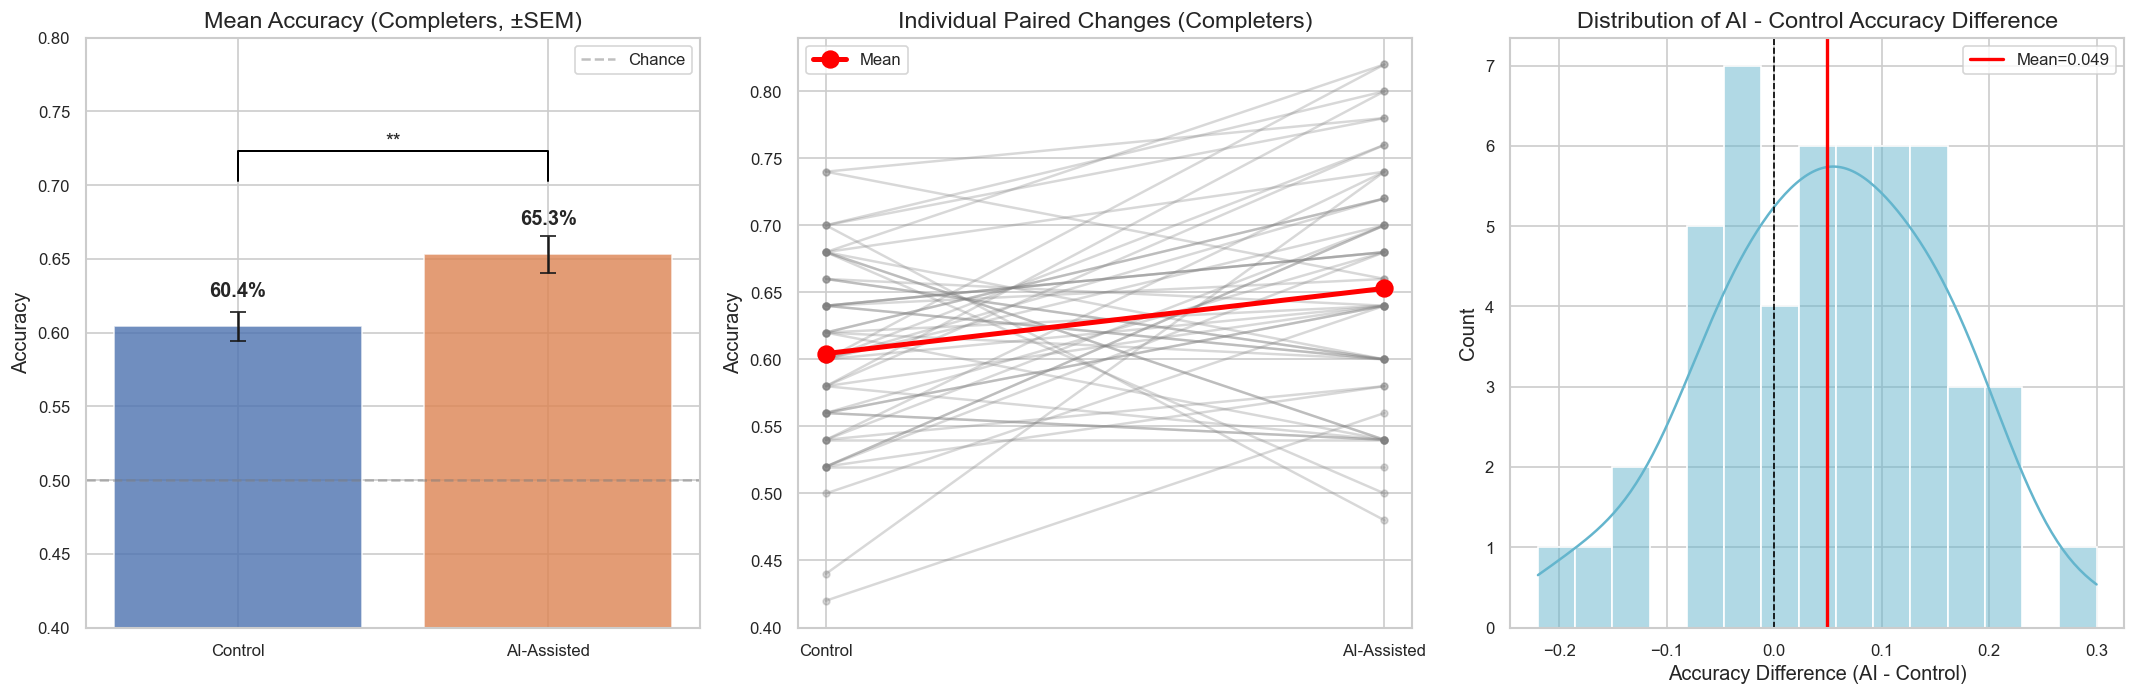

In [4]:
# Visualization: accuracy comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Bar chart with error bars
conditions = ['Control', 'AI-Assisted']
means = [ctrl_paired.mean(), ai_paired.mean()]
sems = [stats.sem(ctrl_paired), stats.sem(ai_paired)]
bars = axes[0].bar(conditions, means, yerr=sems, capsize=5,
                   color=[COLORS['control'], COLORS['ai']], alpha=0.8)
axes[0].set_ylim(0.4, 0.8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Mean Accuracy (Completers, ±SEM)')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
for bar, m in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, m + 0.02, f'{m:.1%}', 
               ha='center', fontweight='bold', fontsize=12)
add_significance(axes[0], 0, 1, max(means) + 0.05, p_pair)
axes[0].legend()

# Paired plot (spaghetti lines)
for _, row in ps_completers.iterrows():
    axes[1].plot([0, 1], [row['control_accuracy'], row['ai_accuracy']], 
               'o-', alpha=0.3, color='gray', markersize=4)
axes[1].plot([0, 1], [ctrl_paired.mean(), ai_paired.mean()], 
           'o-', color='red', linewidth=3, markersize=10, label='Mean', zorder=5)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Control', 'AI-Assisted'])
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Individual Paired Changes (Completers)')
axes[1].legend()

# Difference distribution
sns.histplot(diff, bins=15, ax=axes[2], color=COLORS['neutral'], kde=True)
axes[2].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[2].axvline(x=diff.mean(), color='red', linestyle='-', linewidth=2, label=f'Mean={diff.mean():.3f}')
axes[2].set_title('Distribution of AI - Control Accuracy Difference')
axes[2].set_xlabel('Accuracy Difference (AI - Control)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. Order Effects (Crossover Analysis)

Does the order matter? Compare TG=0 (Control first → then AI) vs TG=1 (AI first → then Control).

In [5]:
# 2×2 Mixed ANOVA: Condition (Control vs AI) × Order (TG0 vs TG1)
# Reshape completers data for mixed ANOVA
anova_data = pd.melt(
    ps_completers[['participant_id', 'treatment_group', 'control_accuracy', 'ai_accuracy']],
    id_vars=['participant_id', 'treatment_group'],
    value_vars=['control_accuracy', 'ai_accuracy'],
    var_name='condition', value_name='accuracy'
)
anova_data['condition'] = anova_data['condition'].map({
    'control_accuracy': 'Control', 'ai_accuracy': 'AI-Assisted'
})

# Mixed ANOVA
aov = pg.mixed_anova(
    data=anova_data, dv='accuracy', 
    within='condition', between='treatment_group', 
    subject='participant_id'
)
print('=== 2×2 Mixed ANOVA (Condition × Order) ===')
display(aov[['Source', 'DF1', 'DF2', 'F', 'p-unc', 'np2']].round(4))

=== 2×2 Mixed ANOVA (Condition × Order) ===


,Source,DF1,DF2,F,p-unc,np2
0,treatment_group,1,49,1.3236,0.2555,0.0263
1,condition,1,49,9.8470,0.0029,0.1673
2,Interaction,1,49,0.0737,0.7872,0.0015


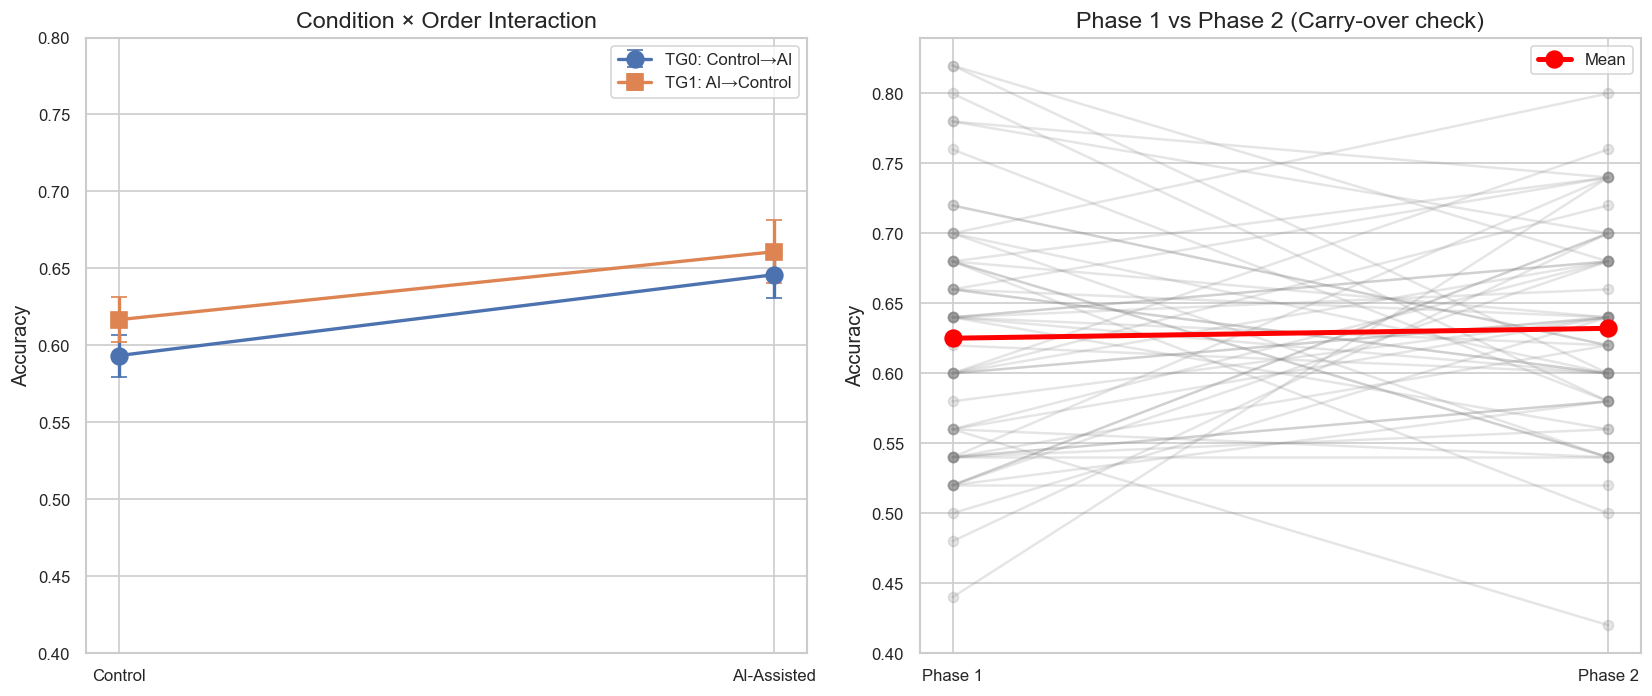

Phase 1 vs 2: t=0.420, p=0.6760


In [6]:
# Visualization: interaction plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Interaction plot
for tg, label, marker in [('0', 'TG0: Control→AI', 'o'), ('1', 'TG1: AI→Control', 's')]:
    subset = ps_completers[ps_completers['treatment_group'] == tg]
    means = [subset['control_accuracy'].mean(), subset['ai_accuracy'].mean()]
    sems = [stats.sem(subset['control_accuracy']), stats.sem(subset['ai_accuracy'])]
    axes[0].errorbar([0, 1], means, yerr=sems, marker=marker, 
                    label=label, linewidth=2, markersize=10, capsize=5)

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Control', 'AI-Assisted'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Condition × Order Interaction')
axes[0].legend()
axes[0].set_ylim(0.4, 0.8)

# Phase 1 vs Phase 2 accuracy (testing carry-over)
phase_acc = completers.groupby(['participant_id', 'phase'])['user_correct'].mean().unstack()
for _, row in phase_acc.iterrows():
    axes[1].plot([0, 1], [row['Phase 1'], row['Phase 2']], 'o-', alpha=0.2, color='gray')
axes[1].plot([0, 1], [phase_acc['Phase 1'].mean(), phase_acc['Phase 2'].mean()],
           'o-', color='red', linewidth=3, markersize=10, label='Mean', zorder=5)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Phase 1', 'Phase 2'])
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Phase 1 vs Phase 2 (Carry-over check)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Phase comparison stats
t_phase, p_phase = stats.ttest_rel(phase_acc['Phase 2'], phase_acc['Phase 1'])
print(f'Phase 1 vs 2: t={t_phase:.3f}, p={p_phase:.4f}')

## 3. AI Influence: Pre-AI vs Post-AI Accuracy

For AI-Assisted trials, compare initial_decision accuracy (before seeing AI) with final_decision accuracy (after seeing AI).  
This directly measures the AI's trial-level influence.

In [7]:
# Trial-level: AI influence
ai_trials = df[df['ai_shown'] == True].copy()

pre_acc = ai_trials['pre_ai_correct'].mean()
post_acc = ai_trials['user_correct'].mean()

print('=== AI Influence (Trial-Level) ===')
print(f'Pre-AI accuracy (initial_decision):  {pre_acc:.3f}')
print(f'Post-AI accuracy (final_decision):   {post_acc:.3f}')
print(f'AI boost (post - pre):               {post_acc - pre_acc:.3f}')
print(f'AI model accuracy:                   {ai_trials["ai_correct"].mean():.3f}')

# McNemar's test: paired binary outcomes on same trials
# Build 2x2 contingency table
a = ((ai_trials['pre_ai_correct']==1) & (ai_trials['user_correct']==1)).sum()  # both correct
b = ((ai_trials['pre_ai_correct']==1) & (ai_trials['user_correct']==0)).sum()  # pre correct, post wrong
c = ((ai_trials['pre_ai_correct']==0) & (ai_trials['user_correct']==1)).sum()  # pre wrong, post correct
d = ((ai_trials['pre_ai_correct']==0) & (ai_trials['user_correct']==0)).sum()  # both wrong

print(f'\nMcNemar contingency: a={a}, b={b} (hurt by AI), c={c} (helped by AI), d={d}')
mcnemar_stat = (b - c)**2 / (b + c) if (b + c) > 0 else 0
mcnemar_p = 1 - stats.chi2.cdf(mcnemar_stat, 1)
print(f'McNemar test: χ²={mcnemar_stat:.3f}, p={mcnemar_p:.4f}')
print(f'Trials helped by AI: {c} ({c/len(ai_trials)*100:.1f}%)')
print(f'Trials hurt by AI:   {b} ({b/len(ai_trials)*100:.1f}%)')

=== AI Influence (Trial-Level) ===
Pre-AI accuracy (initial_decision):  0.599
Post-AI accuracy (final_decision):   0.651
AI boost (post - pre):               0.052
AI model accuracy:                   0.700

McNemar contingency: a=1759, b=68 (hurt by AI), c=226 (helped by AI), d=997
McNemar test: χ²=84.912, p=0.0000
Trials helped by AI: 226 (7.4%)
Trials hurt by AI:   68 (2.2%)


In [8]:
# Participant-level AI influence
print('=== AI Influence (Participant-Level) ===')
ai_influence = ps_all[ps_all['ai_accuracy'].notna()].copy()
ai_influence['ai_boost'] = ai_influence['ai_accuracy'] - ai_influence['ai_pre_ai_accuracy']

print(f'Mean Pre-AI accuracy:  {ai_influence["ai_pre_ai_accuracy"].mean():.3f}')
print(f'Mean Post-AI accuracy: {ai_influence["ai_accuracy"].mean():.3f}')
print(f'Mean AI boost:         {ai_influence["ai_boost"].mean():.3f}')

t_boost, p_boost = stats.ttest_rel(
    ai_influence['ai_accuracy'], ai_influence['ai_pre_ai_accuracy']
)
d_boost = pg.compute_effsize(
    ai_influence['ai_accuracy'], ai_influence['ai_pre_ai_accuracy'], 
    eftype='cohen', paired=True
)
print(f'Paired t-test: t={t_boost:.3f}, p={p_boost:.4f}, d={d_boost:.3f}')

# Who benefited vs who was hurt?
benefited = (ai_influence['ai_boost'] > 0).sum()
hurt = (ai_influence['ai_boost'] < 0).sum()
unchanged = (ai_influence['ai_boost'] == 0).sum()
print(f'\nParticipants benefited: {benefited} ({benefited/len(ai_influence)*100:.0f}%)')
print(f'Participants hurt:     {hurt} ({hurt/len(ai_influence)*100:.0f}%)')
print(f'Unchanged:             {unchanged}')

=== AI Influence (Participant-Level) ===
Mean Pre-AI accuracy:  0.599
Mean Post-AI accuracy: 0.651
Mean AI boost:         0.052
Paired t-test: t=6.989, p=0.0000, d=0.646

Participants benefited: 46 (75%)
Participants hurt:     4 (7%)
Unchanged:             11


In [9]:
# Also compare: Control initial_decision vs Experimental initial_decision (baseline comparison)
ctrl_participants = ps_all[ps_all['control_accuracy'].notna()]
ai_participants = ps_all[ps_all['ai_pre_ai_accuracy'].notna()]

print('=== Baseline Comparison: Control vs Experimental Pre-AI Accuracy ===')
print(f'Control initial accuracy: {ctrl_participants["control_accuracy"].mean():.3f} (n={len(ctrl_participants)})')
print(f'Experimental pre-AI accuracy: {ai_participants["ai_pre_ai_accuracy"].mean():.3f} (n={len(ai_participants)})')

# For completers (paired)
print('\n--- Completers (paired) ---')
t_base, p_base = stats.ttest_rel(
    ps_completers['ai_pre_ai_accuracy'], ps_completers['control_accuracy']
)
print(f'Control: {ps_completers["control_accuracy"].mean():.3f}, Exp pre-AI: {ps_completers["ai_pre_ai_accuracy"].mean():.3f}')
print(f'Paired t-test: t={t_base:.3f}, p={p_base:.4f}')
print('(Non-significant → baselines are equivalent, AI effect is real)')

=== Baseline Comparison: Control vs Experimental Pre-AI Accuracy ===
Control initial accuracy: 0.606 (n=58)
Experimental pre-AI accuracy: 0.599 (n=61)

--- Completers (paired) ---
Control: 0.604, Exp pre-AI: 0.604
Paired t-test: t=-0.030, p=0.9765
(Non-significant → baselines are equivalent, AI effect is real)


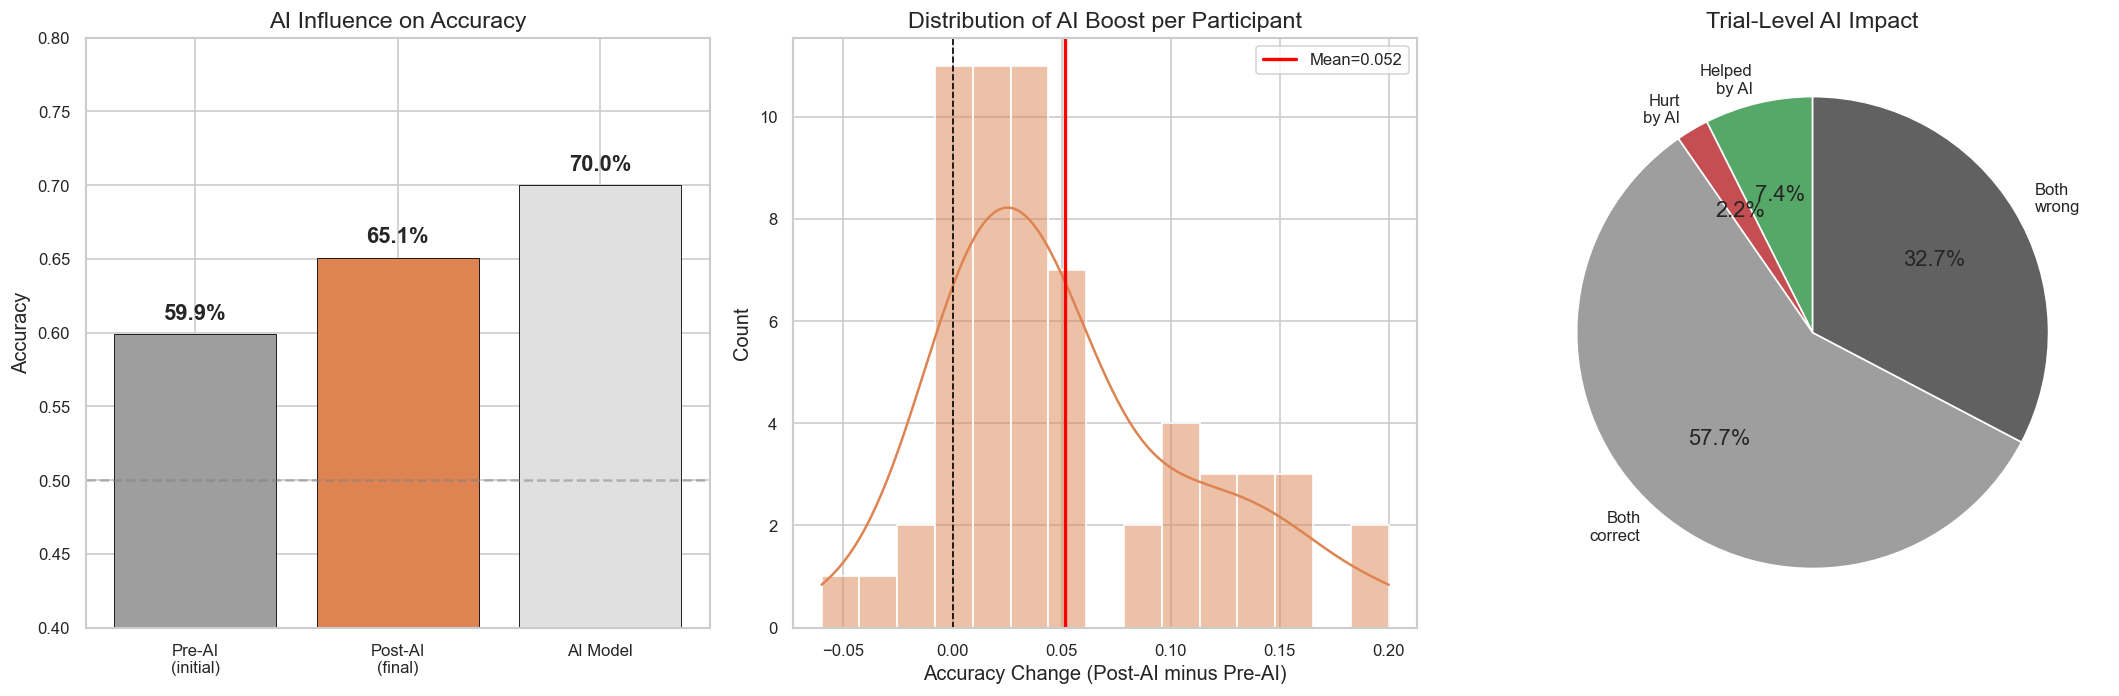

In [10]:
# Visualization: AI influence
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Pre vs Post AI accuracy
acc_data = pd.DataFrame({
    'Pre-AI (initial)': [ai_influence['ai_pre_ai_accuracy'].mean()],
    'Post-AI (final)': [ai_influence['ai_accuracy'].mean()],
    'AI Model': [ai_trials['ai_correct'].mean()]
})
colors = ['#9E9E9E', COLORS['ai'], '#E0E0E0']
bars = axes[0].bar(['Pre-AI\n(initial)', 'Post-AI\n(final)', 'AI Model'], 
                   acc_data.values[0], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylim(0.4, 0.8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('AI Influence on Accuracy')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, acc_data.values[0]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, 
               f'{val:.1%}', ha='center', fontweight='bold')

# AI boost distribution
sns.histplot(ai_influence['ai_boost'], bins=15, ax=axes[1], 
            color=COLORS['ai'], kde=True)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].axvline(x=ai_influence['ai_boost'].mean(), color='red', linewidth=2,
              label=f'Mean={ai_influence["ai_boost"].mean():.3f}')
axes[1].set_title('Distribution of AI Boost per Participant')
axes[1].set_xlabel('Accuracy Change (Post-AI minus Pre-AI)')
axes[1].legend()

# Sankey-like: Trial outcomes (helped, hurt, unchanged)
labels = ['Helped\nby AI', 'Hurt\nby AI', 'Both\ncorrect', 'Both\nwrong']
sizes = [c, b, a, d]  # from McNemar table
colors_pie = [COLORS['correct'], COLORS['incorrect'], '#9E9E9E', '#616161']
axes[2].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[2].set_title('Trial-Level AI Impact')

plt.tight_layout()
plt.show()

## 4. Self-Correction Analysis

When users change their decision after seeing AI (initial ≠ final), how often is it a correction vs an error?

In [11]:
# Self-correction breakdown
changed = ai_trials[ai_trials['decision_changed'] == 1].copy()
not_changed = ai_trials[ai_trials['decision_changed'] == 0].copy()

print(f'=== Decision Changes in AI Trials ===')
print(f'Total AI trials: {len(ai_trials)}')
print(f'Decision changed: {len(changed)} ({len(changed)/len(ai_trials)*100:.1f}%)')
print(f'Decision kept:    {len(not_changed)} ({len(not_changed)/len(ai_trials)*100:.1f}%)')
print()

corrections = changed[changed['changed_to_correct'] == 1]
errors = changed[changed['changed_to_incorrect'] == 1]

print(f'Of changes:')
print(f'  Corrections (wrong→right): {len(corrections)} ({len(corrections)/len(changed)*100:.1f}%)')
print(f'  Errors (right→wrong):      {len(errors)} ({len(errors)/len(changed)*100:.1f}%)')
print(f'  Net benefit:               {len(corrections) - len(errors)} trials')
print()

# Was the change aligned with AI?
changed_to_ai = changed[changed['final_decision'] == changed['ai_prediction']]
changed_away = changed[changed['final_decision'] != changed['ai_prediction']]
print(f'Changed TO agree with AI:   {len(changed_to_ai)} ({len(changed_to_ai)/len(changed)*100:.1f}%)')
print(f'Changed AWAY from AI:       {len(changed_away)} ({len(changed_away)/len(changed)*100:.1f}%)')

=== Decision Changes in AI Trials ===
Total AI trials: 3050
Decision changed: 294 (9.6%)
Decision kept:    2756 (90.4%)

Of changes:
  Corrections (wrong→right): 226 (76.9%)
  Errors (right→wrong):      68 (23.1%)
  Net benefit:               158 trials

Changed TO agree with AI:   279 (94.9%)
Changed AWAY from AI:       15 (5.1%)


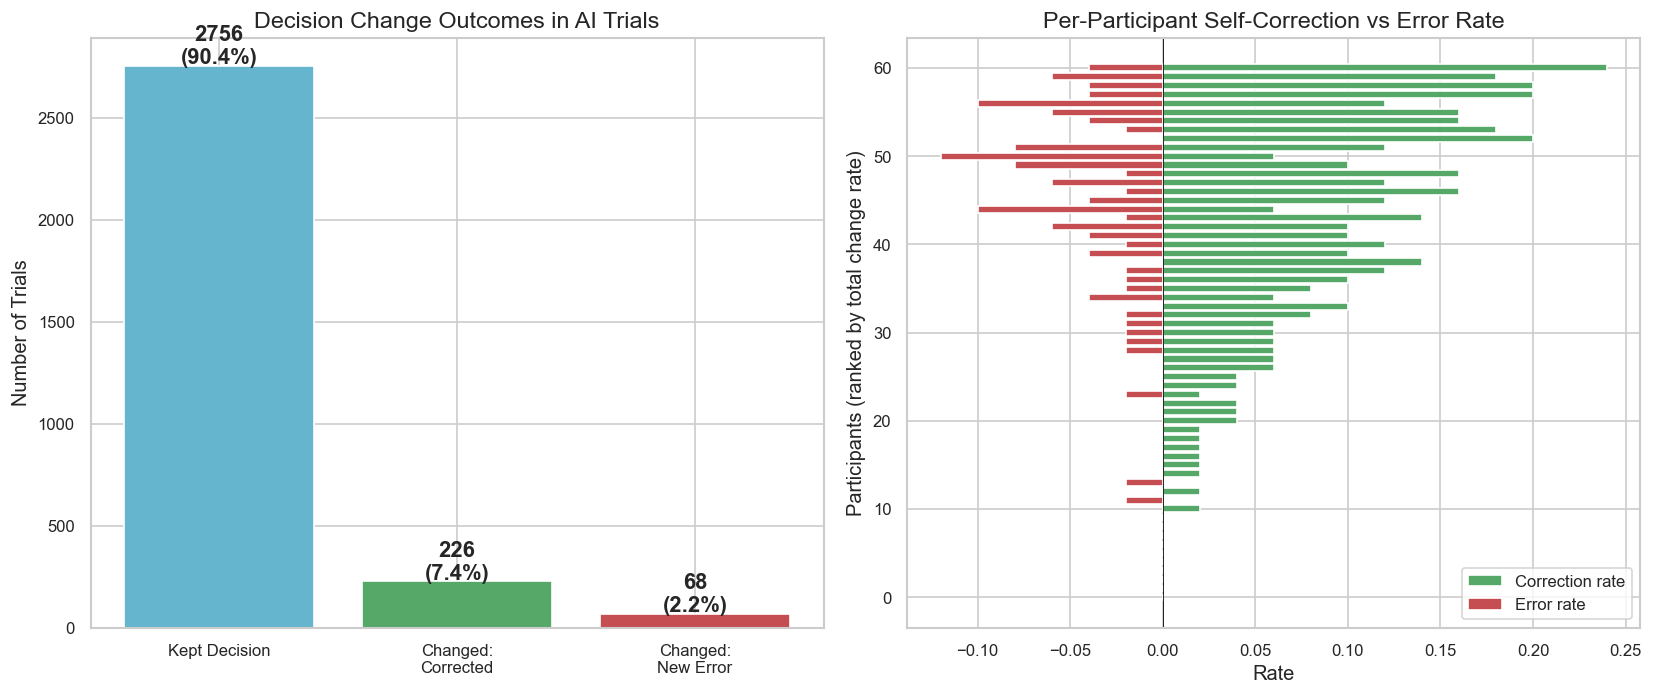

In [12]:
# Visualization: self-correction
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stacked bar: changed vs not, split by outcome
categories = ['Kept Decision', 'Changed:\nCorrected', 'Changed:\nNew Error']
counts = [len(not_changed), len(corrections), len(errors)]
colors_bars = [COLORS['neutral'], COLORS['correct'], COLORS['incorrect']]
bars = axes[0].bar(categories, counts, color=colors_bars)
for bar, c in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, c+10, f'{c}\n({c/len(ai_trials)*100:.1f}%)',
               ha='center', fontweight='bold')
axes[0].set_title('Decision Change Outcomes in AI Trials')
axes[0].set_ylabel('Number of Trials')

# Per-participant self-correction rate
p_corrections = ai_trials.groupby('participant_id').agg(
    correction_rate=('changed_to_correct', 'mean'),
    error_rate=('changed_to_incorrect', 'mean'),
    change_rate=('decision_changed', 'mean')
).sort_values('change_rate', ascending=True)

x = np.arange(len(p_corrections))
axes[1].barh(x, p_corrections['correction_rate'], color=COLORS['correct'], label='Correction rate')
axes[1].barh(x, -p_corrections['error_rate'], color=COLORS['incorrect'], label='Error rate')
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].set_xlabel('Rate')
axes[1].set_ylabel('Participants (ranked by total change rate)')
axes[1].set_title('Per-Participant Self-Correction vs Error Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 5. Accuracy by KL Severity Grade

In [13]:
# Accuracy stratified by KL severity
kl_order = ['healthy', 'doubtful', 'mild', 'moderate', 'severe']

kl_results = df.groupby(['kl_severity', 'condition'])['user_correct'].agg(['mean', 'count', 'std'])
kl_results = kl_results.reset_index()
kl_results['sem'] = kl_results['std'] / np.sqrt(kl_results['count'])

print('=== Accuracy by KL Severity × Condition ===')
display(kl_results.pivot_table(index='kl_severity', columns='condition', values='mean').reindex(kl_order).round(3))

# Chi-square tests per KL grade
print('\n--- Chi-square tests per KL grade ---')
for kl in kl_order:
    subset = df[df['kl_severity'] == kl]
    ctrl_subset = subset[subset['condition'] == 'Control']
    ai_subset = subset[subset['condition'] == 'AI-Assisted']
    
    ct = pd.crosstab(subset['condition'], subset['user_correct'])
    if ct.shape == (2, 2):
        chi2, p, dof, expected = stats.chi2_contingency(ct)
        print(f'  {kl}: χ²={chi2:.2f}, p={p:.4f} (Control={ctrl_subset["user_correct"].mean():.1%} vs AI={ai_subset["user_correct"].mean():.1%})')

=== Accuracy by KL Severity × Condition ===


condition,AI-Assisted,Control
kl_severity,,
healthy,0.572,0.539
doubtful,NaN,NaN
mild,0.597,0.500
moderate,0.923,0.927
severe,0.984,1.000



--- Chi-square tests per KL grade ---
  healthy: χ²=3.18, p=0.0745 (Control=53.9% vs AI=57.2%)
  mild: χ²=16.47, p=0.0000 (Control=50.0% vs AI=59.7%)
  moderate: χ²=0.01, p=0.9090 (Control=92.7% vs AI=92.3%)
  severe: χ²=0.00, p=1.0000 (Control=100.0% vs AI=98.4%)


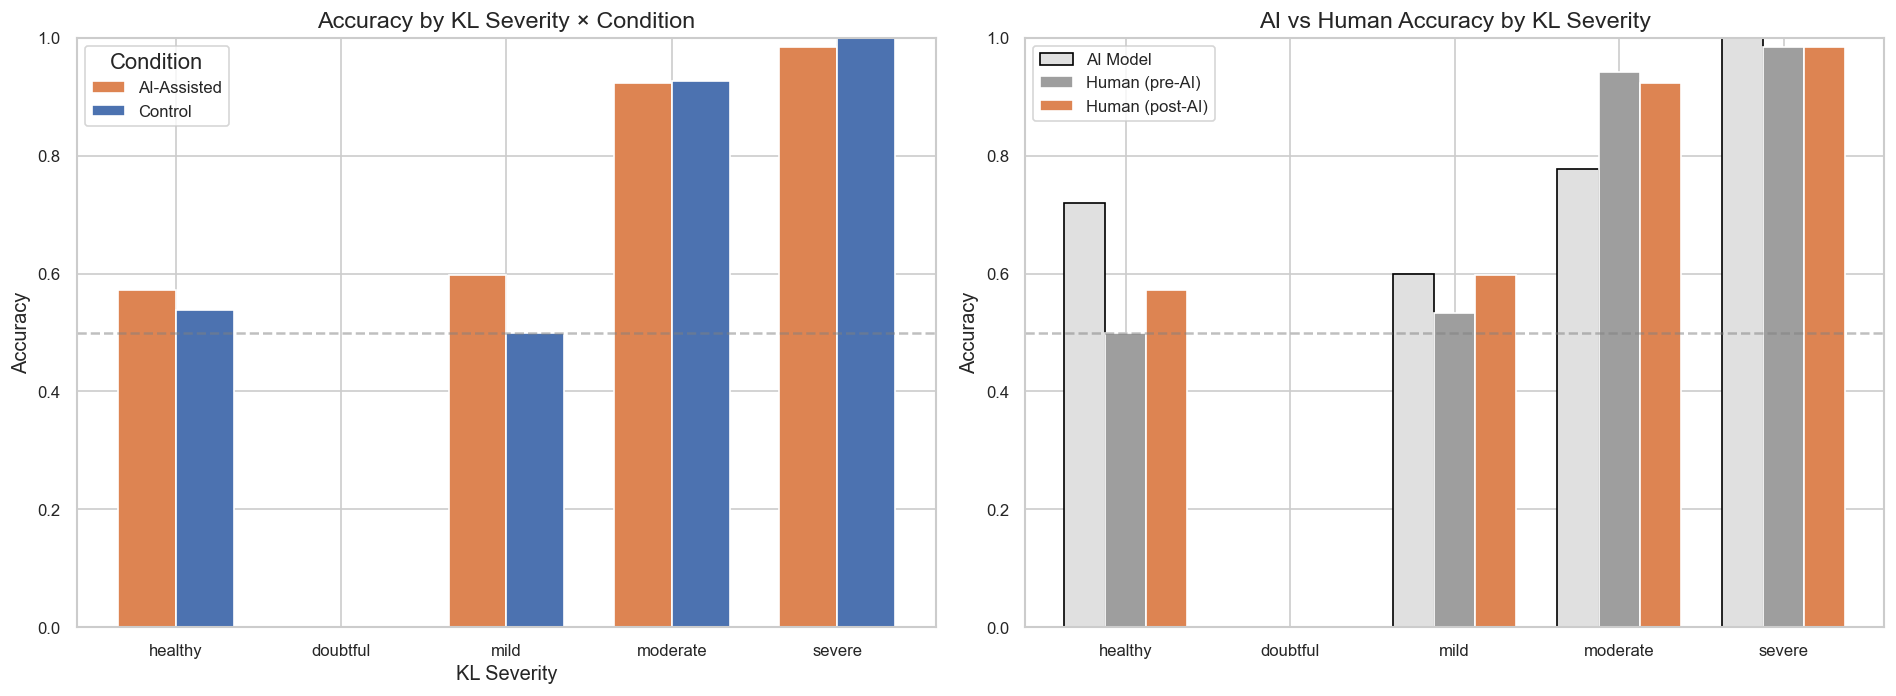

In [14]:
# Visualization: KL severity × condition
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
kl_pivot = kl_results.pivot_table(index='kl_severity', columns='condition', values='mean').reindex(kl_order)
kl_pivot.plot(kind='bar', ax=axes[0], color=[COLORS['ai'], COLORS['control']], width=0.7)
axes[0].set_title('Accuracy by KL Severity × Condition')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('KL Severity')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].legend(title='Condition')
axes[0].tick_params(axis='x', rotation=0)

# AI model accuracy vs human accuracy by KL grade
ai_kl = ai_trials.groupby('kl_severity').agg(
    ai_acc=('ai_correct', 'mean'),
    human_pre=('pre_ai_correct', 'mean'),
    human_post=('user_correct', 'mean')
).reindex(kl_order)

x = np.arange(len(kl_order))
w = 0.25
axes[1].bar(x - w, ai_kl['ai_acc'], w, label='AI Model', color='#E0E0E0', edgecolor='black')
axes[1].bar(x, ai_kl['human_pre'], w, label='Human (pre-AI)', color='#9E9E9E')
axes[1].bar(x + w, ai_kl['human_post'], w, label='Human (post-AI)', color=COLORS['ai'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(kl_order)
axes[1].set_ylim(0, 1)
axes[1].set_title('AI vs Human Accuracy by KL Severity')
axes[1].set_ylabel('Accuracy')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. IQ=0 Sensitivity Analysis

31 of 58 participants with IQ data scored 0. Exploring performance with and without them.

In [15]:
# IQ=0 vs IQ>0 comparison
ps_with_iq = ps_all[ps_all['iq_score'].notna()].copy()
ps_with_iq['iq_group'] = ps_with_iq['iq_score'].apply(lambda x: 'IQ=0' if x == 0 else 'IQ>0')

print('=== IQ=0 vs IQ>0 Performance Comparison ===')
for group in ['IQ=0', 'IQ>0']:
    g = ps_with_iq[ps_with_iq['iq_group'] == group]
    print(f'\n{group} (n={len(g)}):')
    print(f'  Overall accuracy:       {g["overall_accuracy"].mean():.3f} ± {g["overall_accuracy"].std():.3f}')
    if g['control_accuracy'].notna().any():
        print(f'  Control accuracy:       {g["control_accuracy"].mean():.3f}')
    if g['ai_accuracy'].notna().any():
        print(f'  AI accuracy:            {g["ai_accuracy"].mean():.3f}')
    print(f'  Mean trial duration:    {g["overall_mean_duration"].mean():.1f}s')

# Statistical comparison
iq0 = ps_with_iq[ps_with_iq['iq_group'] == 'IQ=0']['overall_accuracy']
iq_pos = ps_with_iq[ps_with_iq['iq_group'] == 'IQ>0']['overall_accuracy']
t_iq, p_iq = stats.ttest_ind(iq_pos, iq0)
d_iq = pg.compute_effsize(iq_pos, iq0, eftype='cohen')
print(f'\nIQ>0 vs IQ=0: t={t_iq:.3f}, p={p_iq:.4f}, d={d_iq:.3f}')

# Sensitivity: re-run main analysis excluding IQ=0
print('\n=== Sensitivity: Main Result Excluding IQ=0 ===')
iq0_pids = set(ps_with_iq[ps_with_iq['iq_group'] == 'IQ=0']['participant_id'])
ps_no_iq0 = ps_completers[~ps_completers['participant_id'].isin(iq0_pids)]

if len(ps_no_iq0) > 1:
    t_sens, p_sens = stats.ttest_rel(ps_no_iq0['ai_accuracy'], ps_no_iq0['control_accuracy'])
    d_sens = pg.compute_effsize(ps_no_iq0['ai_accuracy'], ps_no_iq0['control_accuracy'], 
                                eftype='cohen', paired=True)
    print(f'Completers excl. IQ=0 (n={len(ps_no_iq0)}):')
    print(f'  Control: {ps_no_iq0["control_accuracy"].mean():.3f}, AI: {ps_no_iq0["ai_accuracy"].mean():.3f}')
    print(f'  Paired t: t={t_sens:.3f}, p={p_sens:.4f}, d={d_sens:.3f}')

=== IQ=0 vs IQ>0 Performance Comparison ===

IQ=0 (n=31):
  Overall accuracy:       0.624 ± 0.057
  Control accuracy:       0.606
  AI accuracy:            0.647
  Mean trial duration:    14.5s

IQ>0 (n=27):
  Overall accuracy:       0.632 ± 0.062
  Control accuracy:       0.607
  AI accuracy:            0.659
  Mean trial duration:    16.5s

IQ>0 vs IQ=0: t=0.512, p=0.6105, d=0.135

=== Sensitivity: Main Result Excluding IQ=0 ===
Completers excl. IQ=0 (n=24):
  Control: 0.603, AI: 0.659
  Paired t: t=2.840, p=0.0093, d=0.696


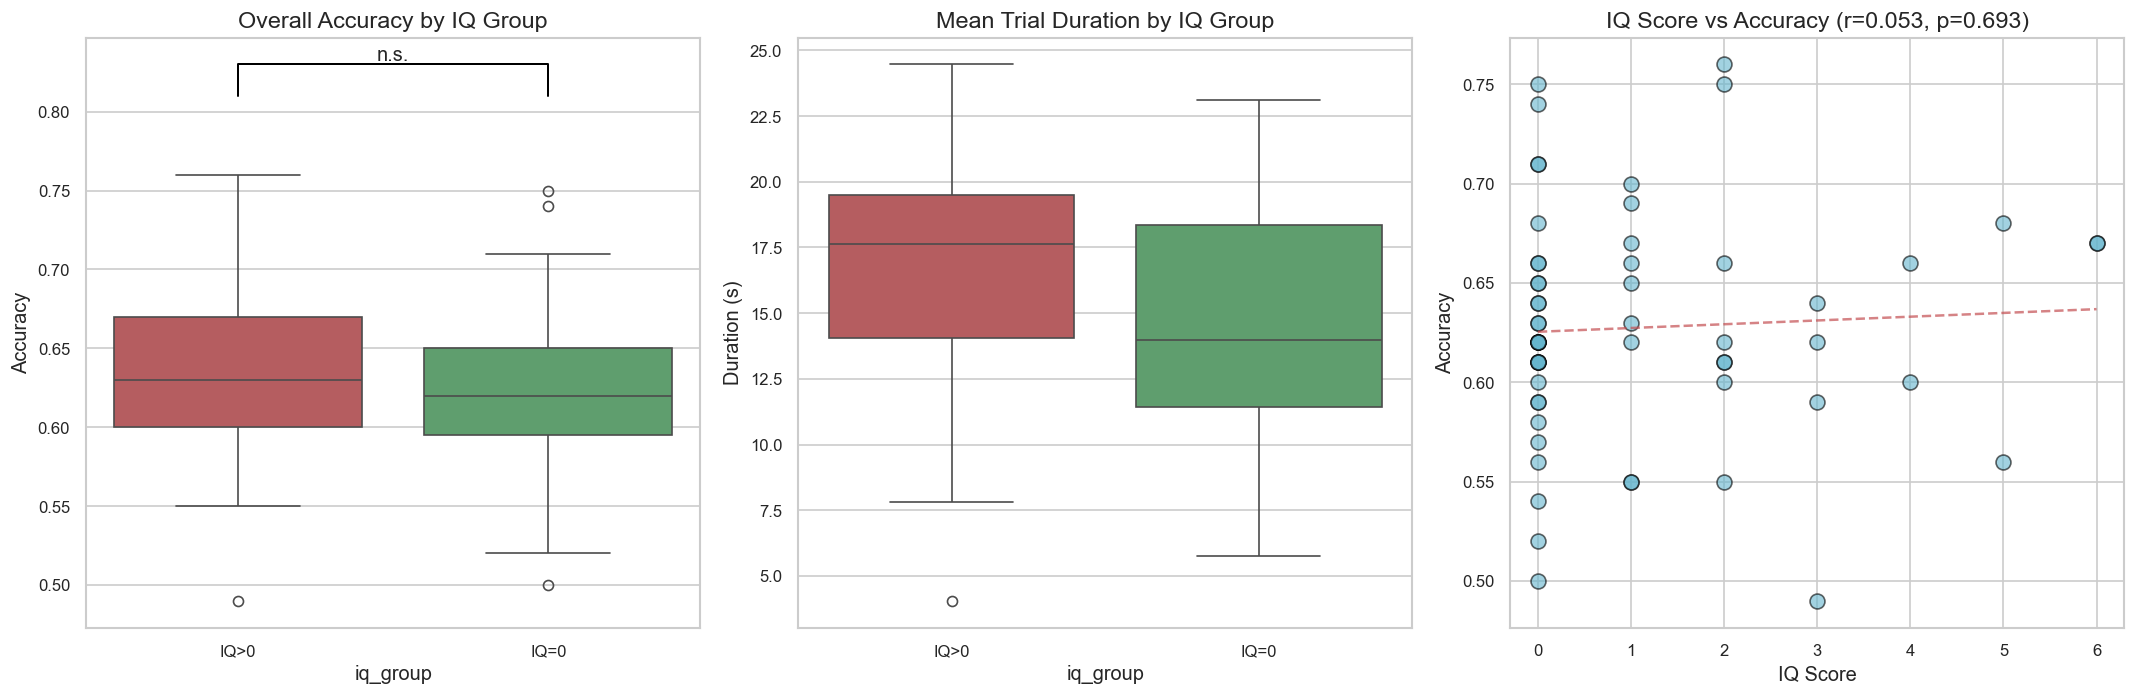

In [16]:
# Visualization: IQ=0 analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Accuracy by IQ group
sns.boxplot(data=ps_with_iq, x='iq_group', y='overall_accuracy', ax=axes[0],
           palette=[COLORS['incorrect'], COLORS['correct']])
axes[0].set_title('Overall Accuracy by IQ Group')
axes[0].set_ylabel('Accuracy')
add_significance(axes[0], 0, 1, ps_with_iq['overall_accuracy'].max() + 0.05, p_iq)

# Trial duration by IQ group
sns.boxplot(data=ps_with_iq, x='iq_group', y='overall_mean_duration', ax=axes[1],
           palette=[COLORS['incorrect'], COLORS['correct']])
axes[1].set_title('Mean Trial Duration by IQ Group')
axes[1].set_ylabel('Duration (s)')

# IQ score vs accuracy scatter
axes[2].scatter(ps_with_iq['iq_score'], ps_with_iq['overall_accuracy'], 
              alpha=0.6, color=COLORS['neutral'], edgecolor='black', s=80)
r, p_r = stats.pearsonr(ps_with_iq['iq_score'], ps_with_iq['overall_accuracy'])
axes[2].set_title(f'IQ Score vs Accuracy (r={r:.3f}, p={p_r:.3f})')
axes[2].set_xlabel('IQ Score')
axes[2].set_ylabel('Accuracy')
# Add regression line
z = np.polyfit(ps_with_iq['iq_score'], ps_with_iq['overall_accuracy'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(ps_with_iq['iq_score'].min(), ps_with_iq['iq_score'].max(), 50)
axes[2].plot(x_line, p_line(x_line), 'r--', alpha=0.7)

plt.tight_layout()
plt.show()

## 7. Chance-Level Participant Detection & Sensitivity Analysis

§7a. Binomial Test: Are Participants Above Chance?
 
Total participants: 68
Significantly above chance (p<0.05): 51 (75.0%)
NOT significantly above chance:      17 (25.0%)

Above-chance group: M=0.654, SD=0.046
At-chance group:    M=0.557, SD=0.050

--- Breakdown by Condition ---
Above-chance: Control=0.624, AI=0.677
At-chance:    Control=0.551, AI=0.555

Control phase: 23/58 above chance (39.7%)
AI phase: 39/61 above chance (63.9%)

§7b. Sensitivity: Main Result Excluding At-Chance Participants
Engaged completers: n=41
Control: M=0.621
AI:      M=0.676
Paired t: t=3.027, p=0.0043, d=0.473



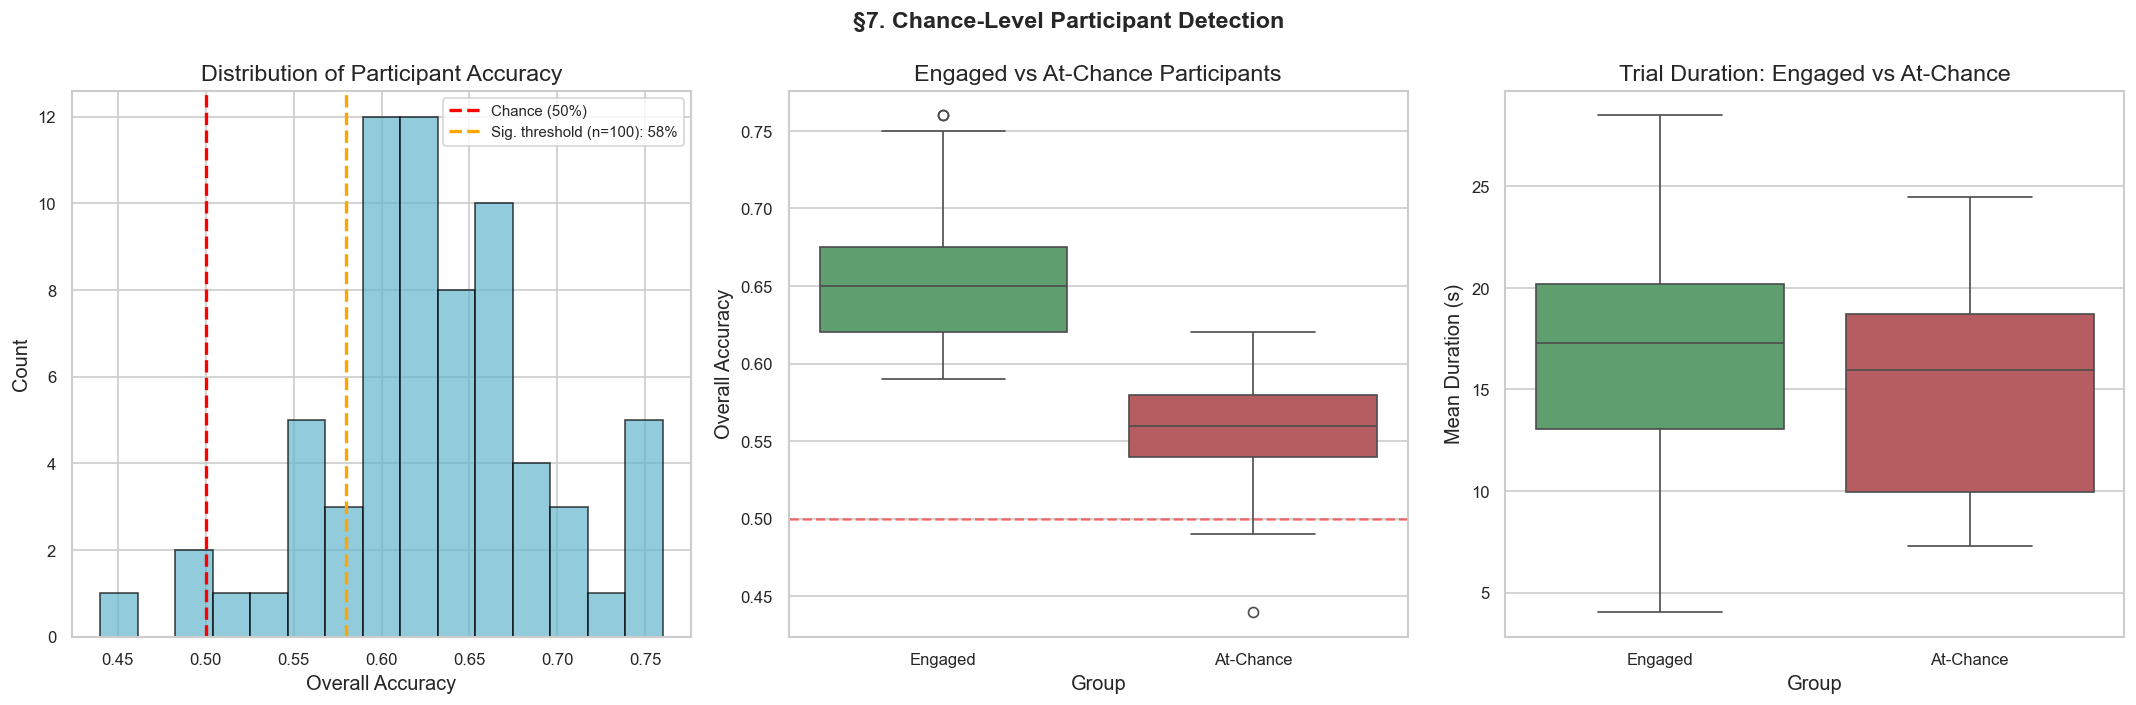

In [17]:
from scipy.stats import binomtest, ttest_rel, ttest_ind, wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns

# --- 7a. Binomial test per participant ---
# H0: participant accuracy = 0.5 (chance on balanced binary task)

ps = get_participant_summary(df)

ps['binom_p'] = ps.apply(
    lambda r: binomtest(
        int(round(r['overall_accuracy'] * r['n_trials'])),
        int(r['n_trials']),
        0.5,
        alternative='greater'
    ).pvalue,
    axis=1
)
ps['above_chance'] = ps['binom_p'] < 0.05

n_above = ps['above_chance'].sum()
n_at_chance = (~ps['above_chance']).sum()

print("§7a. Binomial Test: Are Participants Above Chance?")
print(" ")
print(f"Total participants: {len(ps)}")
print(f"Significantly above chance (p<0.05): {n_above} ({100*n_above/len(ps):.1f}%)")
print(f"NOT significantly above chance:      {n_at_chance} ({100*n_at_chance/len(ps):.1f}%)")
print()
print(f"Above-chance group: M={ps[ps['above_chance']]['overall_accuracy'].mean():.3f}, "
      f"SD={ps[ps['above_chance']]['overall_accuracy'].std():.3f}")
print(f"At-chance group:    M={ps[~ps['above_chance']]['overall_accuracy'].mean():.3f}, "
      f"SD={ps[~ps['above_chance']]['overall_accuracy'].std():.3f}")
print()

# Also check by condition
if 'control_accuracy' in ps.columns:
    above = ps[ps['above_chance']]
    below = ps[~ps['above_chance']]
    print("--- Breakdown by Condition ---")
    print(f"Above-chance: Control={above['control_accuracy'].mean():.3f}, "
          f"AI={above['ai_accuracy'].mean():.3f}")
    print(f"At-chance:    Control={below['control_accuracy'].mean():.3f}, "
          f"AI={below['ai_accuracy'].mean():.3f}")
    print()

# Per-condition binomial test (50 trials each)
for cond, col in [('Control', 'control_accuracy'), ('AI', 'ai_accuracy')]:
    subset = ps[ps[col].notna()].copy()
    n_trials_cond = 50
    subset[f'{cond}_binom_p'] = subset.apply(
        lambda r: binomtest(
            int(round(r[col] * n_trials_cond)),
            n_trials_cond,
            0.5,
            alternative='greater'
        ).pvalue,
        axis=1
    )
    subset[f'{cond}_above_chance'] = subset[f'{cond}_binom_p'] < 0.05
    n_a = subset[f'{cond}_above_chance'].sum()
    print(f"{cond} phase: {n_a}/{len(subset)} above chance "
          f"({100*n_a/len(subset):.1f}%)")
print()

# --- 7b. Sensitivity analysis: main result WITHOUT chance-level participants ---
print("§7b. Sensitivity: Main Result Excluding At-Chance Participants")

engaged_pids = set(ps[ps['above_chance']]['participant_id'])
df_engaged = df[df['participant_id'].isin(engaged_pids)].copy()
ps_engaged = get_participant_summary(df_engaged)
ps_eng_completers = ps_engaged[ps_engaged['is_completer'] &
                                ps_engaged['control_accuracy'].notna() &
                                ps_engaged['ai_accuracy'].notna()]

if len(ps_eng_completers) >= 2:
    t_stat, p_val = ttest_rel(ps_eng_completers['ai_accuracy'],
                               ps_eng_completers['control_accuracy'])
    diff = ps_eng_completers['ai_accuracy'] - ps_eng_completers['control_accuracy']
    d = diff.mean() / diff.std()
    print(f"Engaged completers: n={len(ps_eng_completers)}")
    print(f"Control: M={ps_eng_completers['control_accuracy'].mean():.3f}")
    print(f"AI:      M={ps_eng_completers['ai_accuracy'].mean():.3f}")
    print(f"Paired t: t={t_stat:.3f}, p={p_val:.4f}, d={d:.3f}")
else:
    print("Not enough engaged completers for paired test.")

print()

# --- 7c. Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Histogram of per-participant accuracy with chance threshold
axes[0].hist(ps['overall_accuracy'], bins=15, edgecolor='black', alpha=0.7,
             color=COLORS['neutral'])
axes[0].axvline(x=0.5, color='red', linestyle='--', lw=2, label='Chance (50%)')
# Approximate binomial threshold for n=100 at p<0.05 (one-sided)
from scipy.stats import binom
threshold_100 = binom.ppf(0.95, 100, 0.5) / 100
threshold_50 = binom.ppf(0.95, 50, 0.5) / 50
axes[0].axvline(x=threshold_100, color='orange', linestyle='--', lw=2,
                label=f'Sig. threshold (n=100): {threshold_100:.0%}')
axes[0].set_xlabel('Overall Accuracy')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Participant Accuracy')
axes[0].legend(fontsize=9)

# Engaged vs At-Chance accuracy by condition
data_plot = pd.DataFrame({
    'Group': ['Engaged']*len(ps[ps['above_chance']]) + ['At-Chance']*len(ps[~ps['above_chance']]),
    'Overall Accuracy': list(ps[ps['above_chance']]['overall_accuracy']) +
                        list(ps[~ps['above_chance']]['overall_accuracy'])
})
sns.boxplot(data=data_plot, x='Group', y='Overall Accuracy', ax=axes[1],
            palette=[COLORS['correct'], COLORS['incorrect']])
axes[1].set_title('Engaged vs At-Chance Participants')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

# Speed comparison
data_speed = pd.DataFrame({
    'Group': ['Engaged']*len(ps[ps['above_chance']]) + ['At-Chance']*len(ps[~ps['above_chance']]),
    'Mean Duration (s)': list(ps[ps['above_chance']]['overall_mean_duration']) +
                          list(ps[~ps['above_chance']]['overall_mean_duration'])
})
sns.boxplot(data=data_speed, x='Group', y='Mean Duration (s)', ax=axes[2],
            palette=[COLORS['correct'], COLORS['incorrect']])
axes[2].set_title('Trial Duration: Engaged vs At-Chance')

plt.suptitle('§7. Chance-Level Participant Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Speed vs Accuracy: Is Faster = Worse?

§8a. Speed vs Accuracy (Participant-Level)
 
  Spearman: r=0.119, p=0.3331
  Pearson:  r=0.096, p=0.4361

  Control: r=-0.072, p=0.5922 (n=58)
  AI-Assisted: r=0.063, p=0.6309 (n=61)

--- Accuracy by Speed Quartile ---
                mean_accuracy  std_accuracy  mean_duration   n
speed_quartile                                                
Q1 (fastest)            0.615         0.055          9.745  17
Q2                      0.649         0.063         14.260  17
Q3                      0.622         0.084         18.466  17
Q4 (slowest)            0.632         0.042         22.914  17

Trial-level speed vs accuracy: r=0.001, p=0.9658




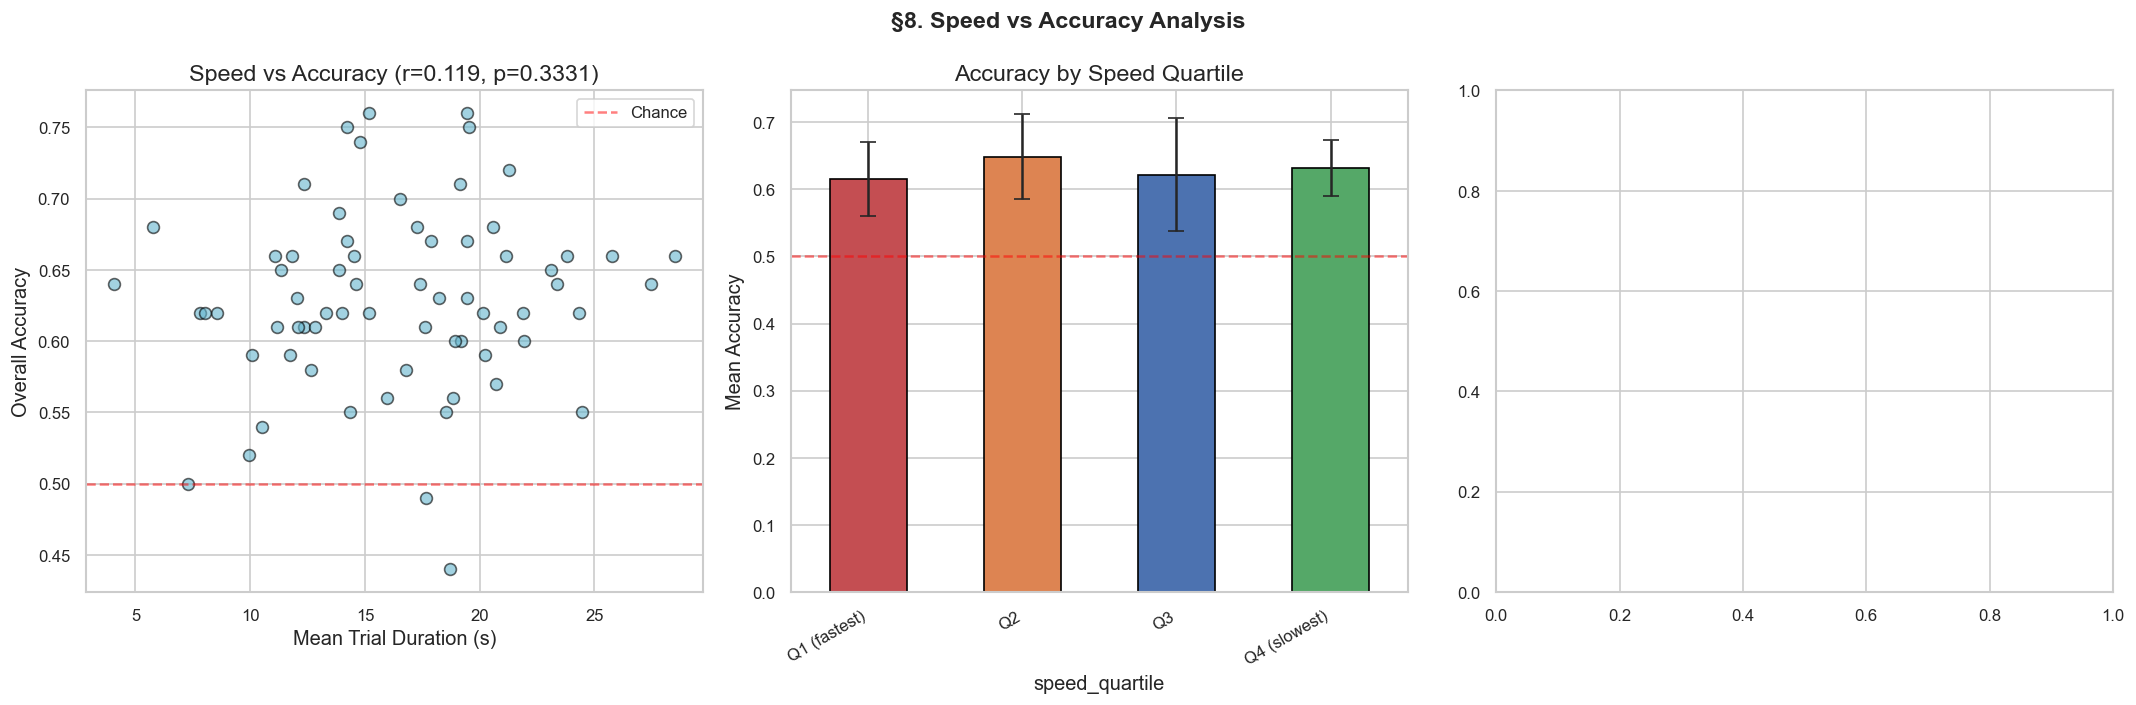

In [18]:
from scipy.stats import spearmanr, pearsonr

ps = get_participant_summary(df)

# --- 8a. Participant-level correlations ---
# Fix: Safely drop missing values from both columns before correlation
ps_subset = ps[['overall_mean_duration', 'overall_accuracy']].dropna()
r_sp, p_sp = spearmanr(ps_subset['overall_mean_duration'], ps_subset['overall_accuracy'])
r_pe, p_pe = pearsonr(ps_subset['overall_mean_duration'], ps_subset['overall_accuracy'])

print("§8a. Speed vs Accuracy (Participant-Level)")
print(" ")
print(f"  Spearman: r={r_sp:.3f}, p={p_sp:.4f}")
print(f"  Pearson:  r={r_pe:.3f}, p={p_pe:.4f}")
print()

# --- 8b. By condition ---
for cond, dur_col, acc_col in [
    ('Control', 'control_mean_duration', 'control_accuracy'),
    ('AI-Assisted', 'ai_mean_duration', 'ai_accuracy'),
]:
    subset = ps[[dur_col, acc_col]].dropna()
    if len(subset) > 5:
        r, p = spearmanr(subset[dur_col], subset[acc_col])
        print(f"  {cond}: r={r:.3f}, p={p:.4f} (n={len(subset)})")
print()

# --- 8c. Quartile analysis ---
ps['speed_quartile'] = pd.qcut(
    ps['overall_mean_duration'], 4,
    labels=['Q1 (fastest)', 'Q2', 'Q3', 'Q4 (slowest)']
)
quartile_stats = ps.groupby('speed_quartile', observed=True).agg(
    mean_accuracy=('overall_accuracy', 'mean'),
    std_accuracy=('overall_accuracy', 'std'),
    mean_duration=('overall_mean_duration', 'mean'),
    n=('overall_accuracy', 'count')
).round(3)

print("--- Accuracy by Speed Quartile ---")
print(quartile_stats)
print()

# --- 8d. Trial-level correlation ---
# Fix: Ensure no NaNs are passed into spearmanr by dropping them jointly
trial_subset = df[['trial_duration', 'user_correct']].dropna()
r_trial, p_trial = spearmanr(trial_subset['trial_duration'], trial_subset['user_correct'])

print(f"Trial-level speed vs accuracy: r={r_trial:.3f}, p={p_trial:.4f}")
print()

# --- 8e. Are fast participants also chance-level? ---
# Cross-tabulate speed quartile × above-chance
if 'above_chance' in ps.columns:
    cross = pd.crosstab(ps['speed_quartile'], ps['above_chance'], margins=True)
    cross.columns = ['At-Chance', 'Above-Chance', 'Total']
    print("--- Speed Quartile × Above-Chance Cross-Tab ---")
    print(cross)
    
    from scipy.stats import chi2_contingency
    # Run chi2 on the non-marginal crosstab
    cross_no_margins = pd.crosstab(ps['speed_quartile'], ps['above_chance'])
    if not cross_no_margins.empty:
        chi2, p_chi, dof, _ = chi2_contingency(cross_no_margins)
        print(f"Chi-square: χ²={chi2:.2f}, p={p_chi:.4f}, dof={dof}")
print()

# --- 8f. Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Scatter
axes[0].scatter(ps_subset['overall_mean_duration'], ps_subset['overall_accuracy'],
                alpha=0.6, c=COLORS['neutral'], edgecolors='black', s=50)
axes[0].set_xlabel('Mean Trial Duration (s)')
axes[0].set_ylabel('Overall Accuracy')
axes[0].set_title(f'Speed vs Accuracy (r={r_sp:.3f}, p={p_sp:.4f})')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[0].legend()

# Quartile bars
quartile_stats['mean_accuracy'].plot(
    kind='bar', ax=axes[1], yerr=quartile_stats['std_accuracy'],
    capsize=5, color=[COLORS['incorrect'], COLORS['ai'],
                      COLORS['control'], COLORS['correct']],
    edgecolor='black'
)
axes[1].set_ylabel('Mean Accuracy')
axes[1].set_title('Accuracy by Speed Quartile')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

# Duration distribution with accuracy coloring
if 'above_chance' in ps.columns:
    # Safely drop missing data for the scatter plot
    ps_scatter = ps.dropna(subset=['overall_mean_duration', 'overall_accuracy', 'above_chance'])
    colors_mapped = ps_scatter['above_chance'].map({True: COLORS['correct'], False: COLORS['incorrect']})
    axes[2].scatter(ps_scatter['overall_mean_duration'], ps_scatter['overall_accuracy'],
                    c=colors_mapped, edgecolors='black', s=50, alpha=0.7)
    axes[2].set_xlabel('Mean Trial Duration (s)')
    axes[2].set_ylabel('Overall Accuracy')
    axes[2].set_title('Engaged (green) vs At-Chance (red)')
    axes[2].axhline(y=0.5, color='red', linestyle='--', alpha=0.3)

plt.suptitle('§8. Speed vs Accuracy Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Batch Effect Test (Two Classroom Cohorts)

Batch distribution (participants):
batch
1    34
2    34
Name: count, dtype: int64

batch          1     2
date                  
2026-02-05  1650     0
2026-02-06     0  1299
2026-03-05  1448     0
2026-03-06     2  1551
§9. Batch Effect Test
Batch 1: n=34
Batch 2: n=34

Metric                       Batch1 M(SD)       Batch2 M(SD)            t       p Sig
------------------------------------------------------------------------------------------
  Overall Accuracy           0.632(0.060)   0.626(0.066)    +0.38  0.7031  
  Control Accuracy           0.593(0.070)   0.621(0.067)    -1.56  0.1251  
  AI Accuracy                0.663(0.085)   0.638(0.092)    +1.09  0.2823  
  Over-Reliance Rate         0.149(0.042)   0.161(0.036)    -1.25  0.2149  
  Skepticism Rate            0.189(0.083)   0.201(0.097)    -0.52  0.6074  
  Mean Duration (s)          17.448(5.210)   15.245(5.153)    +1.75  0.0843  
  Extraversion               3.439(0.739)   3.414(0.637)    +0.14  0.8922  
  Neuroticism   

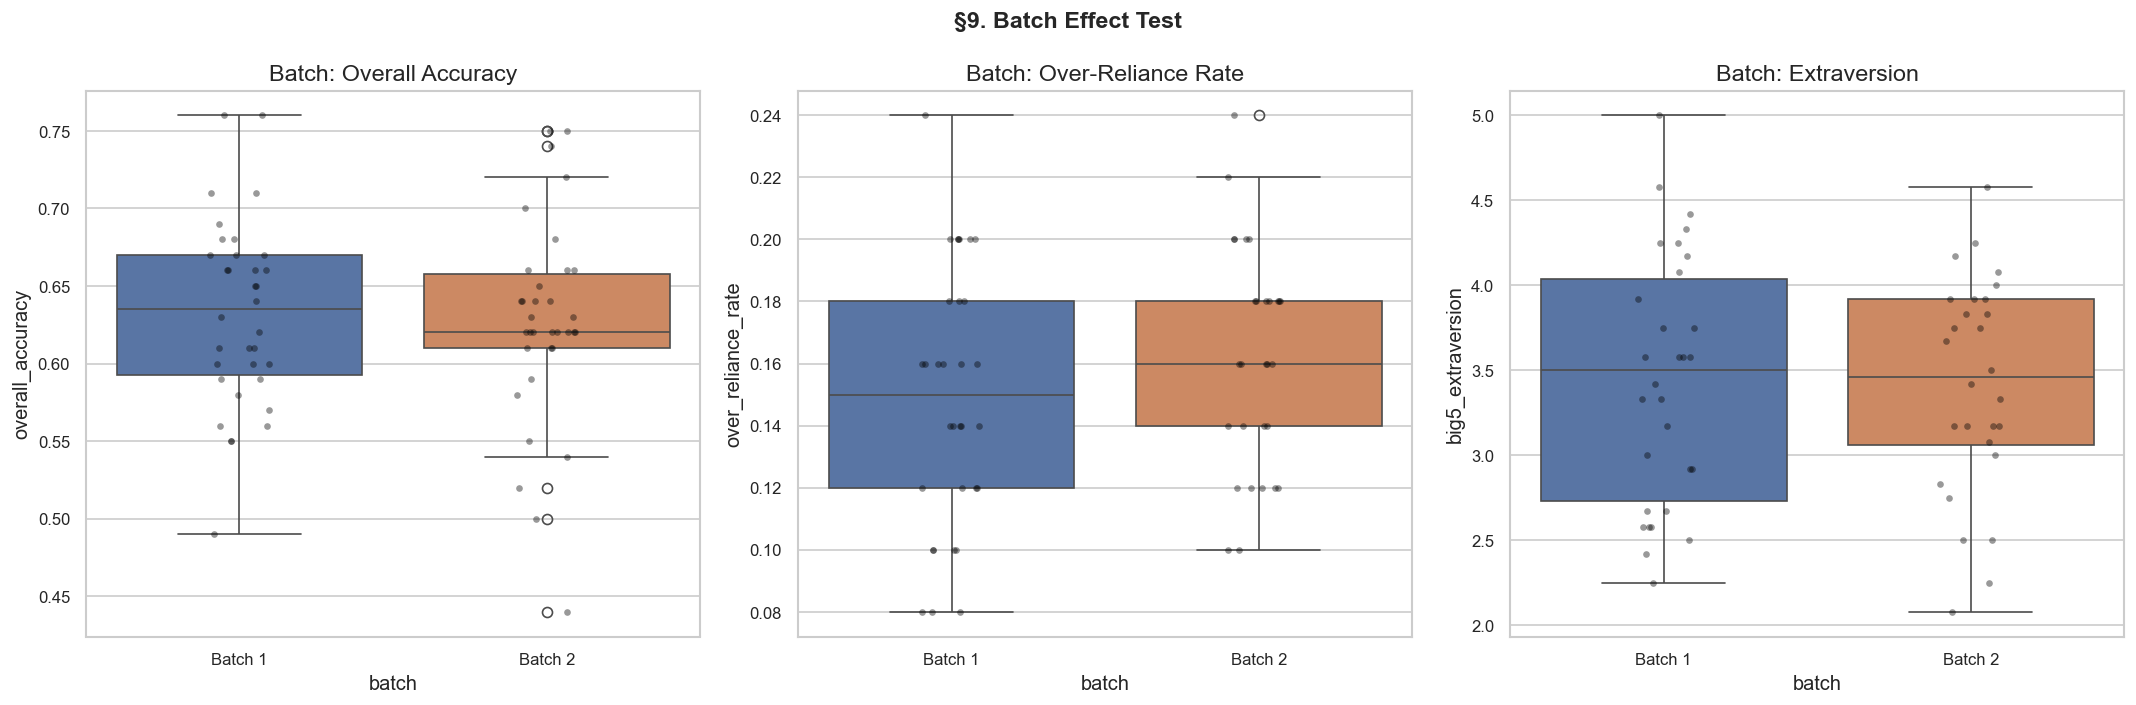

INTERPRETATION:
  If any metric is significant (marked *), batch is a confound
  that should be controlled for in the personality analyses.
  If nothing is significant, batches are equivalent — report as such.


In [19]:
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

df_temp = df[['participant_id', 'trial_start_time']].dropna()
df_temp['datetime'] = pd.to_datetime(df_temp['trial_start_time'], unit='ms', utc=True)
df_temp['day'] = df_temp['datetime'].dt.day  # 5 or 6
# Batch 1: Feb 5 or Mar 5 — Batch 2: Feb 6 or Mar 6
df_temp['batch'] = df_temp['day'].map({5: 1, 6: 2})
# Assign back to main df using per-participant mode
batch_map = df_temp.groupby('participant_id')['batch'].agg(
    lambda x: x.mode()[0] if x.notna().any() else pd.NA
)
df['batch'] = df['participant_id'].map(batch_map)
# Verify
print("Batch distribution (participants):")
print(df.groupby('participant_id')['batch'].first().value_counts().sort_index())
print()
# Sanity: also show date × batch breakdown
df_temp2 = df[['participant_id','trial_start_time','batch']].dropna()
df_temp2['date'] = pd.to_datetime(df_temp2['trial_start_time'], unit='ms', utc=True).dt.date
print(pd.crosstab(df_temp2['date'], df_temp2['batch']))

# ── Check batch column exists ──
if 'batch' not in df.columns:
    print("⚠  Add a 'batch' column to df before running this section.")
    print("   See the comment above for options A and B.")
else:
    ps_batch = get_participant_summary(df)
    ps_batch['batch'] = ps_batch['participant_id'].map(
        df.groupby('participant_id')['batch'].first()
    )
    
    b1 = ps_batch[ps_batch['batch'] == 1]
    b2 = ps_batch[ps_batch['batch'] == 2]
    
    print("=" * 60)
    print("§9. Batch Effect Test")
    print("=" * 60)
    print(f"Batch 1: n={len(b1)}")
    print(f"Batch 2: n={len(b2)}")
    print()

    metrics = [
        ('overall_accuracy',   'Overall Accuracy'),
        ('control_accuracy',   'Control Accuracy'),
        ('ai_accuracy',        'AI Accuracy'),
        ('over_reliance_rate', 'Over-Reliance Rate'),
        ('skepticism_rate',    'Skepticism Rate'),
        ('overall_mean_duration', 'Mean Duration (s)'),
        ('big5_extraversion',  'Extraversion'),
        ('big5_neuroticism',   'Neuroticism'),
        ('big5_conscientiousness', 'Conscientiousness'),
    ]

    print(f"{'Metric':<28} {'Batch1 M(SD)':<18} {'Batch2 M(SD)':<18} {'t':>6} {'p':>7} {'Sig'}")
    print("-" * 90)
    for col, label in metrics:
        s1 = b1[col].dropna()
        s2 = b2[col].dropna()
        if len(s1) < 3 or len(s2) < 3:
            continue
        t, p = ttest_ind(s1, s2)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f"  {label:<26} {s1.mean():.3f}({s1.std():.3f})   "
              f"{s2.mean():.3f}({s2.std():.3f})   {t:+6.2f}  {p:.4f}  {sig}")
    print()

    # Gender / school distribution per batch
    print("── Demographic Distribution by Batch ──")
    for var in ['gender', 'school', 'treatment_group']:
        if var in ps_batch.columns:
            ct = pd.crosstab(ps_batch['batch'], ps_batch[var])
            chi2, p_chi, dof, _ = chi2_contingency(ct)
            print(f"  {var}: χ²={chi2:.2f}, p={p_chi:.4f}")
    print()

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, (col, label) in zip(axes, [
        ('overall_accuracy', 'Overall Accuracy'),
        ('over_reliance_rate', 'Over-Reliance Rate'),
        ('big5_extraversion', 'Extraversion'),
    ]):
        data_plot = ps_batch[[col, 'batch']].dropna()
        data_plot['batch'] = data_plot['batch'].map({1: 'Batch 1', 2: 'Batch 2'})
        sns.boxplot(data=data_plot, x='batch', y=col, ax=ax,
                    palette=[COLORS['control'], COLORS['ai']])
        sns.stripplot(data=data_plot, x='batch', y=col, ax=ax,
                      color='black', alpha=0.4, size=4)
        ax.set_title(f'Batch: {label}')
    plt.suptitle('§9. Batch Effect Test', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("INTERPRETATION:")
    print("  If any metric is significant (marked *), batch is a confound")
    print("  that should be controlled for in the personality analyses.")
    print("  If nothing is significant, batches are equivalent — report as such.")


## Findings & Next Steps

**Summarize key findings here after running the notebook:**

1. Control vs AI accuracy comparison (paired & independent)
2. Order effects (any significant interaction?)
3. AI influence magnitude (pre vs post accuracy)
4. Self-correction: net benefit of decision changes
5. KL severity: which grades are hardest?
6. IQ=0 sensitivity: does exclusion change the main result?

**Next**: NB2 for detailed Human-AI interaction analysis (over-reliance, skepticism, calibration).